# 1. Implement Real Business Cycle Model in MATLAB, Dynare, Python and Julia

DING Minjie, Spring 2025

In this tutorial, we will talk about:

* 1. A Simple RBC Model Setting
* 2. RBC Model in MATLAB
* 3. Introduction to Dynare
* 4. RBC Model in Dynare
* 5. RBC Model with Occasional Binding
* 6. RBC Model in Python
* 7. RBC Model in Julia

_________________________________________________________________________________________________________________________________________________

# 1. A Simple RBC Model Setting

_________________________________________________________________________________________________________________________________________________

## Households

The households maximize:

$$
\max E_{t}\left[\sum_{j=0}^{\infty} \beta^{j}\left\{\frac{C_{t+j}^{1-1 / \sigma}}{1-1 / \sigma}-\phi \frac{N_{t+j}^{1+1 / \eta}}{1+1 / \eta}\right\}\right],
$$

where:

- $C$ is consumption.
- $N$ is labor.
- $\sigma$ is the intertemporal elasticity of substitution (IES).
- $\eta$ is the Frisch elasticity of labor supply (the elasticity of hours worked to the wage rate). 

Households face two constraints:

$$
\begin{aligned}
\lambda: & C_{t}+I_{t}=W_{t} N_{t}+R_{t} K_{t} \\
q: & K_{t+1}=K_{t}(1-\delta)+I_{t}
\end{aligned}
$$

where:

- $K$ is total investment in physical capital.


## Firm

Firms maximize:

$$
\Pi_{t}=Y_{t}-W_{t} N_{t}-R_{t} K_{t}
$$

where the production function is:

$$
Y_{t}=A_{t} K_{t}^{\alpha} N_{t}^{1-\alpha}
$$

We assume total factor productivity (TFP) evolves in an AR(1) process:

$$
log(A_t) = \rho log(A_{t-1}) + \sigma \epsilon_t
$$


## Recursive competitive equilibrium

A Recursive Competitive Equilibrium consists of:
- Pricing functions: $W(K, A), R(K, A)$
- Policy functions of individual households: $K^{\prime}(K, A), N(K, A), C(K, A)$
- Law of motion of TFP: $A^{\prime} \sim Q\left(A^{\prime} \mid A\right)$

which satisfy:
1. Given $W(K, A), R(K, A)$ and rational expectations about future aggregates, $K^{\prime}(K, A), N(K, A), C(K, A)$ are optimal.
2. Given $W(K, A), R(K, A)$, firms solve the maximization problem.
3. Markets clear: Labor market (trivial); Capital market (trivial); Goods market: $Y_{t}=C_{t}+I_{t}$.


An possible way to solve the model is to get a system of difference equations that govern the dynamical system, and then analyze those difference equations directly as we did before (without solving for the full equilibrium).

In particular, from the first-order conditions (FOCs) from maximization problems and constraints (including goods market clearing condition), we can derive the following 9 equations for 9 endogenous variables: $ N_{t}, W_{t}, C_{t}, Y_{t}, I_{t}, K_{t+1}, Z_{t}, q_{t}, R_{t} $. Note that some of the variables can be consolidated $ N_{t}, W_{t}, Y_{t}, I_{t}, q_{t}, R_{t} $.

## Optimality conditions consist of a system of 8 equations




FOCs from households' maximization problem:

$$
\begin{align*}
 C_{t}^{-1 / \sigma} = \beta \mathbb{E} [(1+ R_t -\delta) C_{t+1}^{-1 / \sigma}] \tag{1}
\end{align*}
$$



$$
\begin{align*}
\phi N_{t}^{1 / \eta} = W_{t} C_{t}^{-1 / \sigma} \tag{2}
\end{align*}
$$

FOCs from firms' maximization problem:

$$
\begin{align*}
 Y_{t} = A_{t} K_{t}^{\alpha} N_{t}^{1-\alpha} \tag{3}
\end{align*}
$$

$$
\begin{align*}
 R_{t}K_t = \alpha A_{t} K_{t}^{\alpha} N_{t}^{1-\alpha} = \alpha Y_t \tag{4}
\end{align*}
$$

$$
\begin{align*} 
W_{t} N_t = (1-\alpha) A_{t} K_{t}^{\alpha} N_{t}^{1 -\alpha} = (1-\alpha) Y_t \tag{5}
\end{align*}
$$

Law of motions and market clearing:

$$
\begin{align*}
 K_{t+1} = K_{t}(1-\delta) + I_{t} \tag{6}
 \end{align*}
 $$

$$
\begin{align*}
 Y_{t} = C_{t} + I_{t} \tag{7}
 \end{align*}
 $$

$$
\begin{align*} 
log(A_t) = \rho log(A_{t-1}) + \sigma \epsilon_t \tag{8}
\end{align*}
$$

Sometimes, law of motion of TFP is set as follows:

- $A_{t+1} = \rho A_{t} + (1-\rho) \bar{A} + \varepsilon_{t+1} $

## Calibration and solve steady state

Usually, we try to solve steady state first, and then impulse response function.

It is clear that the quantitative result of the model depends on the value of parameters used. So we need to "calibrate" these parameters appropriately.

The central idea of calibration is to pin down as many deep parameters as possible.
- Directly estimated from the data: Hall's estimation about IES (0.2).
  For simplicity, I set **$\sigma=1$**, in this way $\frac{1}{\sigma}=1$ as well.
- Match the moments from the data: **$ \beta=0.99 $** to match the capital-output ratio, which is about 10 in quarterly data.
- Commonly used parameter values (for a quarterly model):
  - **$ \delta=0.025 $** (10 percent annual depreciation rate).
  - **$ \alpha=0.35 $** (Share of labor income in the aggregate data).
  - **$ \rho=0.95 $** (TFP process is estimated to be very persistent).
  - **$ \eta=1 $** (for simplicity).

How about **$\phi$**? 

We set it so that $N$ equals to 1/3 in steady state. 

Besides, we set $A=1$ (sometimes people set $Y=1$).

**Step 1: solve intertemporal price**

From equation $2$, we have:

$$\beta * (1 + R - \delta) = 1$$

**Step 2: get ratio between $K$, $N$ and $Y$ in production side**





Equation 4 over equation 3, and we get relation between capital $K$ and labor $N$:

$$\frac{N}{K} = (\frac{R}{A\alpha})^{\frac{1}{1-\alpha}} = (\frac{\frac{1}{\beta}+\delta-1 }{A\alpha})^{\frac{1}{1-\alpha}}$$

Combined with equation 3, we have relation between output $Y$, capital $K$ and labor $N$:

$$\frac{Y}{K} = A (\frac{N}{K})^{1-\alpha}$$

**Step 3: together with $C$ in households**

From equation 6 and equation 7, in steady state:

$$Y-C=\delta K$$

Based on what we get in step 2:

$$\frac{C}{K} = A (\frac{N}{K})^{1-\alpha}-\delta $$

**Step 4: get $\phi$**

From equation 5:

$$ W = (1-\alpha) \frac{Y}{N} = (1-\alpha)\frac{Y}{K} \frac{K}{N}$$

Add information from equation 2:

$$
\phi N^{\frac{\sigma}{\eta}+1} = (1-\alpha) A (\frac{N}{K})^{1-\alpha} \frac{K}{C}
$$

The RHS right hand side is what we already know. 

The LHS, we have value for $\sigma$ and $\eta$.

All we need is to choose a value for $\phi$, so that $N=\frac{1}{3}$.

Now, we can get steady state.

From $\beta * (1 + R - \delta) = 1$, $\beta=0.99$, $\delta=0.25$, we get: **$R=0.0351$**.

From $\frac{N}{K} = (\frac{R}{A\alpha})^{\frac{1}{1-\alpha}}$, $A=1$, $N=\frac{1}{3}$, we have: $K=11.3$.

From $\frac{Y}{K} = A (\frac{N}{K})^{1-\alpha}$, we have: $Y=1.13$.

From $Y-C=\delta K$, we have: $C=0.86$.

And then, $W=2.20$, $\phi=7.8$.

_________________________________________________________________________________________________________________________________________________

# 2. Real Business Cycle Model in MATLAB

_________________________________________________________________________________________________________________________________________________________

Now I am going to implement RBC model in MATLAB.

You can skip this part if you prefer Dynare.

First, let's set the working directory and clear the environment.

In [ ]:
cd"C:\Users\ading\A_TA_Notes"
pwd

ans = 'C:\Users\ading\A_TA_Notes'

In [ ]:
clear all;
clc;
close all;

Then, let's set the parameters.

In [ ]:
nX = 8;          % Number of variables
nEps = 1;       % Number of epsilon variables

% Define indices, which will be used for plot
% I arranged them according to the order 
% in which they appear in the equilibrium solution
iA = 1;         
iR = 2;
iN = 3;
iK = 4;
iY = 5;
iC = 6;
iI = 7;
iW = 8;

In [ ]:
% parameters 
alpha = 0.35;    % capital share
beta = 0.99;     % discount factor
gamma = 1;       % risk aversion
eta = 1;         % labor elasticity
delta = 0.025;   % depreciation rate
rho = 0.95;      % TFP persistency
phi = 7.8;       % labor disutility

Here is steady state solution.

In [ ]:
%%file SteadyState.m

function X = SteadyState(beta, delta, alpha, nX)
    A = 1;
    R = 1 / beta - 1 + delta;
    N = 1/3;
    K = N * (R/A/alpha)^(1/(alpha-1));
    Y = A * K^alpha * N^(1-alpha);
    C = Y - delta * K;
    I = delta*K;
    W = (1-alpha)*Y/N;

    X = zeros(nX, 1);  % Initialize X as a column vector
    X([1, 2, 3, 4, 5, 6, 7, 8]) = [A; R; N; K; Y; C; I; W];  % Assign values to X (adjust indices for MATLAB)
end


File SteadyState.m created successfully.

In [ ]:
% Call the SteadyState function
X_SS = SteadyState(beta, delta, alpha, nX);  % Ensure you provide the required parameters

epsilon_SS = 0.0;

% Display the steady state
fprintf('Steady state: %s\n', mat2str(X_SS));

Steady state: [1;0.0351010101010102;0.333333333333333;11.4660753507223;1.14991664772756;0.863264763959503;0.286651883768057;2.24233746306874]


Then, construct jacobian matrix. 

A_jacobian_raw measures how a small change in future variable affect system equilibrium.

B_jacobian_raw measures how a small change in current variable affect system equilibrium.

C_jacobian_raw measures how a small change in past variable affect system equilibrium.

E_jacobian_raw measures how a small change in TFP shock affect system equilibrium.

In [ ]:
syms A R N K Y C I W A_P R_P N_P K_P Y_P C_P I_P W_P A_L R_L N_L K_L Y_L C_L I_L W_L epsilon

residuals = [...
        beta * (1+R-delta) * C_P^(-1/gamma) * C^(1/gamma) - 1.0; % Euler equation
        phi * N^(1/eta) - W*C^(-1/gamma);   
        A * K_L^alpha * N^(1-alpha) - Y; % Production function
        alpha * A * K_L^(alpha-1) * N^(1-alpha) - R; % MPK
        (1-alpha) * A * K_L^alpha * N^(-alpha) - W; % MPN
        (1 - delta) * K_L + I_L - K; % Aggregate resource constraint 
        % Do not use (1 - delta) * K + I - K_P
        Y - C - I; % Aggregate resource constraint
        rho * log(A_L) + epsilon - log(A) % TFP evolution
    ];

A_jacobian_raw = jacobian(residuals, [A_P,R_P,N_P,K_P,Y_P,C_P,I_P,W_P])
B_jacobian_raw = jacobian(residuals, [A,  R,  N,  K,  Y,  C,  I,  W  ])
C_jacobian_raw = jacobian(residuals, [A_L,R_L,N_L,K_L,Y_L,C_L,I_L,W_L])   % don't name it C, otherwise confused with consumption C
E_jacobian_raw = jacobian(residuals, epsilon)

Plug in values to get jacobian matrix.

In [ ]:
X = SteadyState(beta, delta, alpha, nX);
A_s = X(1);
R_s = X(2);
N_s = X(3);
K_s = X(4);
Y_s = X(5);
C_s = X(6);
I_s = X(7);
W_s = X(8);

X_Lag = SteadyState(beta, delta, alpha, nX);
A_L_s = X_Lag(1);
R_L_s = X_Lag(2);
N_L_s = X_Lag(3);
K_L_s = X_Lag(4);
Y_L_s = X_Lag(5);
C_L_s = X_Lag(6);
I_L_s = X_Lag(7);
W_L_s = X_Lag(8);

X_Prime = SteadyState(beta, delta, alpha, nX);
A_P_s = X_Prime(1);
R_P_s = X_Prime(2);
N_P_s = X_Prime(3);
K_P_s = X_Prime(4);
Y_P_s = X_Prime(5);
C_P_s = X_Prime(6);
I_P_s = X_Prime(7);
W_P_s = X_Prime(8);

In [ ]:
A_jacobian = subs(A_jacobian_raw, {A R N K Y C I W A_P R_P N_P K_P Y_P C_P I_P W_P A_L R_L N_L K_L Y_L C_L I_L W_L epsilon}, ...
{A_s R_s N_s K_s Y_s C_s I_s W_s A_P_s R_P_s N_P_s K_P_s Y_P_s C_P_s I_P_s W_P_s A_L_s R_L_s N_L_s K_L_s Y_L_s C_L_s I_L_s W_L_s 0});
A_jacobian = round(double(A_jacobian), 4)

B_jacobian = subs(B_jacobian_raw, {A R N K Y C I W A_P R_P N_P K_P Y_P C_P I_P W_P A_L R_L N_L K_L Y_L C_L I_L W_L epsilon}, ...
{A_s R_s N_s K_s Y_s C_s I_s W_s A_P_s R_P_s N_P_s K_P_s Y_P_s C_P_s I_P_s W_P_s A_L_s R_L_s N_L_s K_L_s Y_L_s C_L_s I_L_s W_L_s 0});
B_jacobian = round(double(B_jacobian), 4)

C_jacobian = subs(C_jacobian_raw, {A R N K Y C I W A_P R_P N_P K_P Y_P C_P I_P W_P A_L R_L N_L K_L Y_L C_L I_L W_L epsilon}, ...
{A_s R_s N_s K_s Y_s C_s I_s W_s A_P_s R_P_s N_P_s K_P_s Y_P_s C_P_s I_P_s W_P_s A_L_s R_L_s N_L_s K_L_s Y_L_s C_L_s I_L_s W_L_s 0});
C_jacobian = round(double(C_jacobian), 4)

E_jacobian = subs(E_jacobian_raw, {A R N K Y C I W A_P R_P N_P K_P Y_P C_P I_P W_P A_L R_L N_L K_L Y_L C_L I_L W_L epsilon}, ...
{A_s R_s N_s K_s Y_s C_s I_s W_s A_P_s R_P_s N_P_s K_P_s Y_P_s C_P_s I_P_s W_P_s A_L_s R_L_s N_L_s K_L_s Y_L_s C_L_s I_L_s W_L_s 0});
E_jacobian = round(double(E_jacobian), 4)

A_jacobian = 8×8 double
         0         0         0         0         0   -1.1584         0         0
         0         0         0         0         0         0         0         0
         0         0         0         0         0         0         0         0
         0         0         0         0         0         0         0         0
         0         0         0         0         0         0         0         0
         0         0         0         0         0         0         0         0
         0         0         0         0         0         0         0         0
         0         0         0         0         0         0         0         0

B_jacobian = 8×8 double
         0    0.9900         0         0         0    1.1584         0         0
         0         0    7.8000         0         0    3.0089         0   -1.1584
    1.1499         0    2.2423         0   -1.0000         0         0         0
    0.0351   -1.0000    0.0684         0         0         0         0         0
    2.2423         0   -2.3545         0         0         0         0   -1.0000
         0         0         0   -1.0000         0         0         0         0
         0         0         0         0    1.0000   -1.0000   -1.0000         0
   -1.0000         0         0         0         0         0         0         0

C_jacobian = 8×8 double
         0         0         0         0         0         0         0         0
         0         0         0         0         0         0         0         0
         0         0         0    0.0351         0         0         0         0
         0         0         0   -0.0020         0         0         0         0
         0         0         0    0.0684         0         0         0         0
         0         0         0    0.9750         0         0    1.0000         0
         0         0         0         0         0         0         0         0
    0.9500         0         0         0         0         0         0         0

E_jacobian = 8×1 double
     0
     0
     0
     0
     0
     0
     0
     1

Then solve for P and Q.

Here P satisfies: $C + B*P + A*P*P = 0$,

and Q satisfies: $Q = -inv(B + A * P) * E $

P measures how system absorbs changes over time.

Q measures how eps shock affect system over time.

In [ ]:
%%file SolveSystem.m

function [P, Q] = SolveSystem(A, B, C, E)
    % Solve the system using linear time iteration as in Rendahl (2017)
    MAXIT = 1000;    
    P = zeros(size(A));  % Initialize P with the same size as A

    for it = 1:MAXIT
        % Solve for P using least squares
        P = - (B + A * P) \ C;  % Equivalent to np.linalg.lstsq in Python   

        % Test the convergence condition
        test = max(abs(C + B * P + A * P * P));  % Check C + B*P + A*P*P = 0
        if test < 1e-7
            break;
        end
    end

    % Impact matrix
    % Solution is x_{t} = P*x_{t-1} + Q*eps_t
    Q = -inv(B + A * P) * E ;  % Q = - E * (B + A*P)

end

File SolveSystem.m created successfully.

In [ ]:

% Assuming A, B, C, and E are defined matrices
[P, Q] = SolveSystem(A_jacobian, B_jacobian, C_jacobian, E_jacobian);

% Display the results
disp('Matrix P:');
disp(P);

disp('Matrix Q:');
disp(Q);

Matrix P:
    0.9500         0         0    0.0000         0         0    0.0000         0
    0.0444         0         0   -0.0024         0         0   -0.0008         0
    0.1611         0         0   -0.0052         0         0   -0.0121         0
         0         0         0    0.9750         0         0    1.0000         0
    1.4537         0         0    0.0234         0         0   -0.0272         0
    0.2564         0         0    0.0446         0         0    0.0424         0
    1.1973         0         0   -0.0212         0         0   -0.0695         0
    1.7508         0         0    0.0807         0         0    0.0285         0

Matrix Q:
    1.0000
    0.0467
    0.1696
         0
    1.5302
    0.2699
    1.2604
    1.8430



Finally, let's plot the impulse response functions. 

In [ ]:
% Assuming nX, Q, and P are defined
IRF_RBC = zeros(nX, 100);  % Initialize IRF_RBC with zeros
IRF_RBC(:, 1) = Q * 0.01;   % Set the first column

for t = 2:100  % MATLAB indices start at 1
    IRF_RBC(:, t) = P * IRF_RBC(:, t - 1);  % Matrix multiplication
end

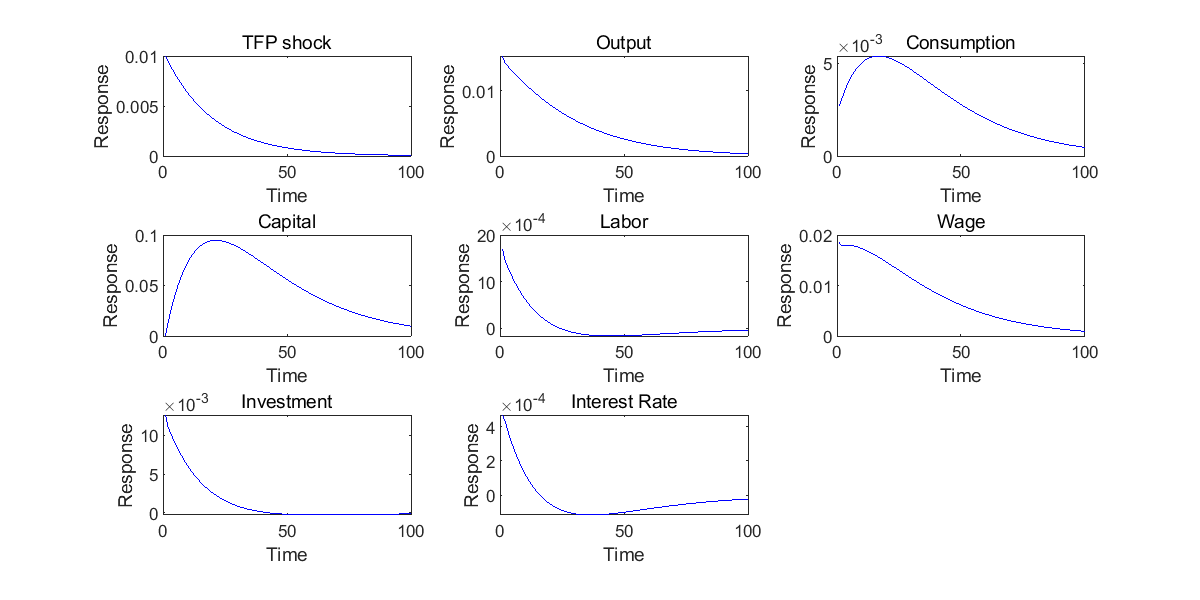

In [ ]:
figure('Position', [100, 100, 800, 400]);  

subplot(3,3,1)
plot(IRF_RBC(iA, :), 'blue', 'DisplayName', 'Impulse Response of Output');  % Plot the data
title('TFP shock'); xlabel('Time'); ylabel('Response');

subplot(3,3,2)
plot(IRF_RBC(iY, :), 'blue', 'DisplayName', 'Impulse Response of Output');  % Plot the data
title('Output'); xlabel('Time'); ylabel('Response');

subplot(3,3,3)
plot(IRF_RBC(iC, :), 'blue', 'DisplayName', 'Impulse Response of Output');  % Plot the data
title('Consumption'); xlabel('Time'); ylabel('Response');

subplot(3,3,4)
plot(IRF_RBC(iK, :), 'blue', 'DisplayName', 'Impulse Response of Output');  % Plot the data
title('Capital'); xlabel('Time'); ylabel('Response');

subplot(3,3,5)
plot(IRF_RBC(iN, :), 'blue', 'DisplayName', 'Impulse Response of Output');  % Plot the data
title('Labor'); xlabel('Time'); ylabel('Response');

subplot(3,3,6)
plot(IRF_RBC(iW, :), 'blue', 'DisplayName', 'Impulse Response of Output');  % Plot the data
title('Wage'); xlabel('Time'); ylabel('Response');

subplot(3,3,7)
plot(IRF_RBC(iI, :), 'blue', 'DisplayName', 'Impulse Response of Output');  % Plot the data
title('Investment'); xlabel('Time'); ylabel('Response');

subplot(3,3,8)
plot(IRF_RBC(iR, :), 'blue', 'DisplayName', 'Impulse Response of Output');  % Plot the data
title('Interest Rate'); xlabel('Time'); ylabel('Response');

As we can see, almost all variable increase after a positive TFP shock.

These figures are the same as what we will get by Dynare, except for the magnitute, since we plot absolute value here, and plot percentage change in Dynare.

_________________________________________________________________________________________________________________________________________________

# 3. Introduction to Dynare

_________________________________________________________________________________________________________________________________________________

Dynare is a software platform for handling a wide class of economic models, in particular dynamic stochastic general equilibrium (DSGE) and overlapping generations (OLG) models. 

We can use Dynare to:
- compute the steady state of a model;
- compute the first, second order, or higher order approximation to solutions of stochastic models;
- estimate parameters of DSGE models using either a maximum likelihood or a Bayesian approach.

## Steps to install Dynare
- Install Matlab.
- Download at https://www.dynare.org/download/.
- Install (manual 2.2.1).
- Configure (manual 2.4).

To configure, personally I recommend to use 'addpath d:/dynare/6.2/matlab'

Sometimes people will use menu entries: 

"Set Path" > "Add Folder. . . " > 

If you use this method, take care not to click "Add Folder and Sub Folder..."

## Version Choice

Dynare now has updated to version 6. While some literature's replication package is based on version 4. 

A possible solution is to install MATLAB of different versions in your computer. 

For each MATLAB version, choose a Dynare version for it. 

In this way, you can replicate certain literature using Dynare 4, and try new functions using Dynare 6.

## .mod file

Structure of a .mod file:
- Preamble: parameters, variables
- Model
- Initial Value, End Value
- Steady State
- Shocks
- Computation

To run a .mod code, type `dynare xxxx.mod` in the command window.

______________________________________________________________________________________________________________________________________

# 4. Real Business Cycle Model in Dynare

______________________________________________________________________________________________________________________________________

We follow the model setting in part 1. 

A typical .mod file consist of 7 parts:

    1. variable
    2. parameters
    3. model
    4. initial value
    5. shocks
    6. steady
    7. simulation

Here is an example. 

<span style="color:green">
    
var y I k a c w R n; <br>
varexo e;

</span>

<span style="color:green">

parameters alpha beta delta rho gamma sigmae eta phi;<br>
alpha=0.35;<br>
beta=0.99;<br>
delta=0.025;<br>
rho=0.95;<br>
gamma=1;<br>
sigmae=0.01;<br>
eta = 1;<br>
phi = 7.6;<br>

</span>

In model part, there are 8 equations. 

They are exactly the equilibiurm conditions we get in part 8. 

Remember the 8 equations in tag 1~8. 

Note that here all variables are in log, so that we can get percentage change in the final result. 

<span style="color:green">

model;<br>
% equation 1<br>
exp(c)^(-1/gamma)=beta*exp(c(+1))^(-1/gamma)*(exp(R)+1-delta);

% equation 2<br>
exp(c)^(-1/gamma)*exp(w)=phi*exp(n)^(1/eta);

% equation 3<br>
exp(y)=exp(a)*exp(k(-1))^alpha*exp(n)^(1-alpha);

% equation 4<br>
exp(R)=alpha*exp(a)*exp(k(-1))^(alpha-1)*exp(n)^(1-alpha);

% equation 5<br>
exp(w)=(1-alpha)*exp(a)*exp(k(-1))^alpha*exp(n)^(-alpha);

% equation 6<br>
exp(k)=exp(I(-1))+(1-delta)*exp(k(-1));

% equation 7<br>
exp(y)=exp(c)+exp(I);

% equation 8<br>
a=rho*a(-1)+e;     

end;

</span>

We had better give initial value to Dynare, so that we can get reasonable solution when there are multiple solutions. 

It can be numbers assigned, or formula based on parameters. 

In the following code, it's the steady state that we get in part 1.

Also, note that variables are in log. 

<span style="color:green">
    
initval;<br>

a = 0; <br>
n = log(1/3); <br>
R = log(1/beta - 1 + delta);<br>
k = log(exp(n)*(exp(R)/exp(a)/alpha)^(1/(alpha-1)));<br>
y = log(exp(a)*exp(k)^alpha*exp(n)^(1-alpha));<br>
I = log(delta)+k;<br>
c = log(exp(y)-exp(I));<br>
w = log(1-alpha) + y - n;<br>

</span>

<span style="color:green">

shocks; <br>
var e = sigmae^2; <br>
end; <br>

</span>

<span style="color:green">

steady;

</span>

<span style="color:green">

stoch_simul(order=1,irf=100);

</span>

Let's see the result from Dynare

In [ ]:
cd"C:\Users\ading\A_TA_Notes"
pwd

ans = 'C:\Users\ading\A_TA_Notes'

Starting Dynare (version 6.2).
Calling Dynare with arguments: none
Starting preprocessing of the model file ... 
Found 8 equation(s). 
Evaluating expressions... 
Computing static model derivatives (order 1). 
Normalizing the static model... 
Finding the optimal block decomposition of the static model... 
2 block(s) found: 
  1 recursive block(s) and 1 simultaneous block(s). 
  the largest simultaneous block has 7 equation(s) 
                                 and 7 feedback variable(s). 
Computing dynamic model derivatives (order 1). 
Normalizing the dynamic model... 
Finding the optimal block decomposition of the dynamic model... 
2 block(s) found: 
  1 recursive block(s) and 1 simultaneous block(s). 
  the largest simultaneous block has 7 equation(s) 
                                 and 7 feedback variable(s). 
Preprocessing completed. 
Preprocessing time: 0h00m00s.

STEADY-STATE RESULTS:

a 		 0
y 		 0.0441673
c 		 -0.226868
k 		 2.29508
n 		 -1.08129
w 		 0.719991
I 		 -1.3938
R 		

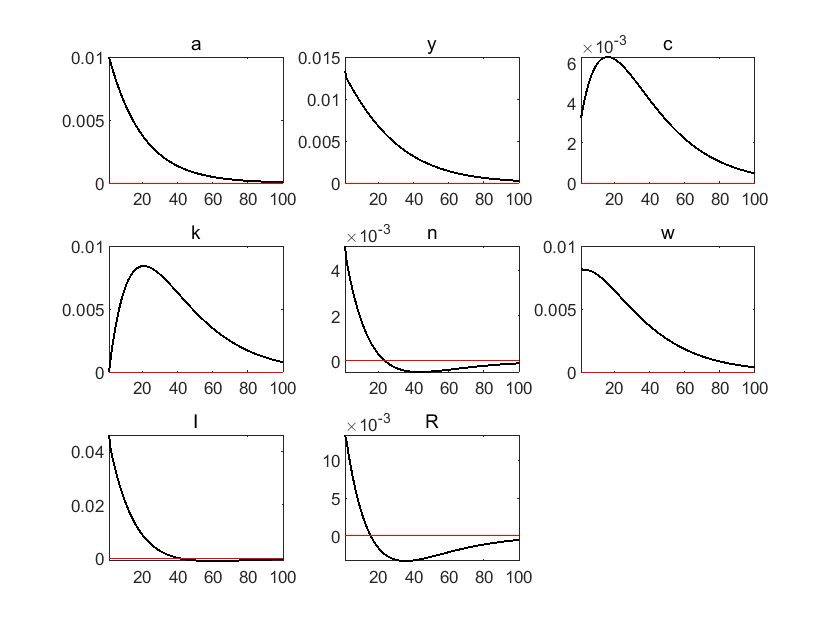

Total computing time : 0h00m01s


In [ ]:
dynare rbc_8equations.mod

_________________________________________________________________________________________________________________________________________________

# 5. RBC Model with Occasional Binding

_________________________________________________________________________________________________________________________________________________

Occasional Binding Constraints refer to situations in economic models where certain constraints are not always active but can become binding under specific conditions. 

OccBin is an important tool developed by Guerrieri and Iacoviello (JME, 2015).

Dynare manual provides an example on how to set up occasional binding model.

There are two occasionally binding constraints newly added into RBC model:
 *  1. The INEG constraint implements quadratic capital adjustment costs if investment falls below its steady state. If investment is above steady state, there are no adjustment costs
 *  2. The IRR constraint implements irreversible investment. Investment cannot be lower than a factor $phi$ of its steady state.

We list all variables first.

<span style = "color:green">

var A           $A$         (long_name='TFP')<br>
    C           $C$         (long_name='consumption')<br>
    Invest      $I$         (long_name='investment')<br>
    K           $K$         (long_name='capital')<br>
    Lambda      $\lambda$   (long_name='Lagrange multiplier')<br>
    log_K       ${\hat K}$  (long_name='log capital')<br>
    log_Invest  ${\hat I}$  (long_name='log investment')<br>
    log_C       ${\hat C}$  (long_name='log consumption')<br>
    ;

varexo epsilon $\varepsilon$        (long_name='TFP shock');

</span>

Then we set parameters.

<span style = "color:green">
parameters alpha    $\alpha$        (long_name='capital share') <br>
        delta       $\delta$        (long_name='depreciation')<br>
        beta        $\beta$         (long_name='discount factor')<br>
        sigma       $\sigma$        (long_name='risk aversion')<br>
        rho         $\rho$          (long_name='autocorrelation TFP')<br>
        phi         $\phi$          (long_name='irreversibility fraction of steady state investment')<br>
        psi         $\psi$          (long_name='capital adjustment cost')<br>
        ;

beta=0.96;<br>
alpha=0.33;<br>
delta=0.10;<br>
sigma=2;<br>
rho = 0.9;<br>
phi = 0.975;<br>
psi = 5;<br>

</span>

The model is set as follows. 

In equation 2, when INEG binds, there is extra adjustment cost: psi(K/K(-1)-1)^2.

In equation 4, when IRR binds, investment equals to phi*investment_steadystate, investment can't be lower, and Lambda is larger than zero. 

<span style = "color:green">
model;<br>
// 1.<br>
[name='Euler', bind = 'INEG']<br>
-C^(-sigma)*(1+2*psi*(K/K(-1)-1)/K(-1))+ beta*C(+1)^(-sigma)*((1-delta)-2*psi*(K(+1)/K-1)*<br>
  (-K(+1)/K^2)+alpha*exp(A(+1))*K^(alpha-1))= -Lambda+beta*(1-delta)*Lambda(+1);<br>

[name='Euler', relax = 'INEG']<br>
-C^(-sigma) + beta*C(+1)^(-sigma)*(1-delta+alpha*exp(A(+1))*K^(alpha-1))= -Lambda+beta*(1-delta)*Lambda(+1);<br>

// 2.<br>
[name='Budget constraint',bind = 'INEG']<br>
C+K-(1-delta)*K(-1)+psi*(K/K(-1)-1)^2=exp(A)*K(-1)^(alpha);<br>

[name='Budget constraint',relax = 'INEG']<br>
C+K-(1-delta)*K(-1)=exp(A)*K(-1)^(alpha);<br>

// 3.<br>
[name='LOM capital']<br>
Invest = K-(1-delta)*K(-1);<br>

// 4.<br>
[name='investment',bind='IRR,INEG']<br>
(log_Invest - log(phi*steady_state(Invest))) = 0;<br>
[name='investment',relax='IRR']<br>
Lambda=0;<br>
[name='investment',bind='IRR',relax='INEG']<br>
(log_Invest - log(phi*steady_state(Invest))) = 0;<br>

// 5.<br>
[name='LOM TFP']<br>
A = rho*A(-1)+epsilon;<br>

// Definitions<br>
[name='Definition log capital']<br>
log_K=log(K);<br>
[name='Definition log consumption']<br>
log_C=log(C);<br>
[name='Definition log investment']<br>
log_Invest=log(Invest);<br>
end;<br>

occbin_constraints;<br>
name 'IRR'; bind log_Invest-log(steady_state(Invest))<log(phi); relax Lambda<0;<br>
name 'INEG'; bind log_Invest-log(steady_state(Invest))<-0.000001; %not exactly 0 for numerical reasons<br>
end;<br>

</span>

The steady state solution is here.

<span style="color:green">
steady_state_model;<br>
K = ((1/beta-1+delta)/alpha)^(1/(alpha-1));<br>
C = -delta*K +K^alpha;<br>
Invest = delta*K;<br>
log_K = log(K);<br>
log_C = log(C);<br>
log_Invest = log(Invest);<br>
Lambda = 0;<br>
A=0;<br>
end;<br>
</span>

Assume there is negative TFP shock at period 1-9, 10 and 50,

there is positive TFP shock at period 90 and 130.

<span style="color:green">
shocks;<br>
  var epsilon; stderr 0.015;<br>
end;<br>

steady;<br>

shocks(surprise);<br>
var epsilon;<br>
periods 1:9, 10, 50, 90, 130, 131:169;<br>
values -0.0001, -0.01,-0.02, 0.01, 0.02, 0;<br>
end;<br>

occbin_setup;<br>
occbin_solver(simul_periods=200,simul_check_ahead_periods=200);<br>

occbin_graph log_C epsilon Lambda log_K log_Invest A;<br>
</span>

After 3 negative TFP shocks, at period 50, IRR condition binds, and there is difference between piecewise linear (occasional binding) and linear case. 

In [ ]:
cd"C:\Users\ading\A_TA_Notes"
pwd

ans = 'C:\Users\ading\A_TA_Notes'

Starting Dynare (version 6.2).
Calling Dynare with arguments: none
Starting preprocessing of the model file ... 
Found 8 equation(s). 
Evaluating expressions... 
Computing static model derivatives (order 1). 
Normalizing the static model... 
Finding the optimal block decomposition of the static model... 
4 block(s) found: 
  3 recursive block(s) and 1 simultaneous block(s). 
  the largest simultaneous block has 2 equation(s) 
                                 and 2 feedback variable(s). 
Computing dynamic model derivatives (order 2). 
Normalizing the dynamic model... 
Finding the optimal block decomposition of the dynamic model... 
3 block(s) found: 
  2 recursive block(s) and 1 simultaneous block(s). 
  the largest simultaneous block has 5 equation(s) 
                                 and 4 feedback variable(s). 
Preprocessing completed. 
Preprocessing time: 0h00m00s.

STEADY-STATE RESULTS:

A          		 0
C          		 1.16335
Invest     		 0.353288
K          		 3.53288
Lambda     	

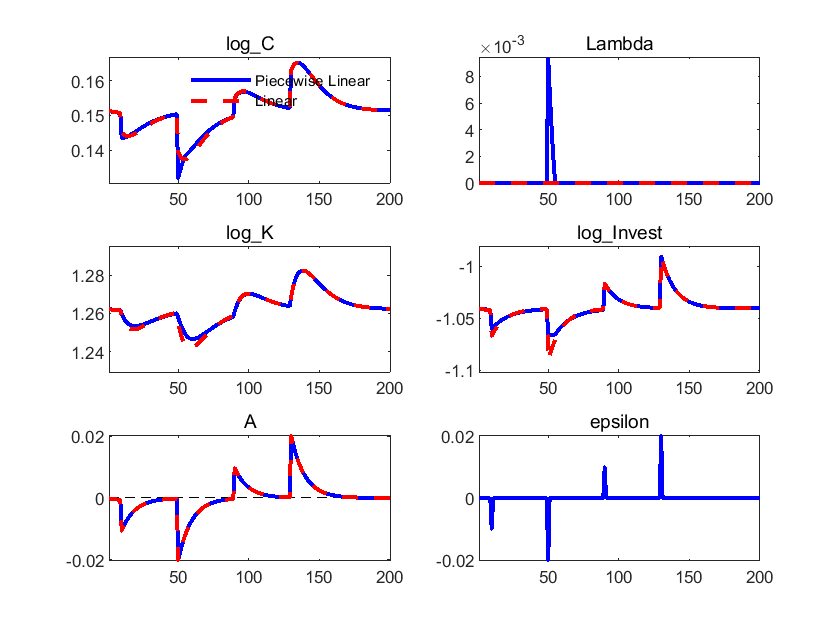

Total computing time : 0h00m02s


In [ ]:
dynare Occbin_example.mod

_____________________________________________________________________________________________________________________________________________

# Reference

_________________________________________________________________________________________________________________________________________________

1. Dynare Manual, https://www.dynare.org/manual/

2. Pontus Rendahl, "Linear Time Iteration", Institute for Advanced Studies

3. Alisdair Mckay, "Computational Notes on Heterogeneous-Agent Macroeconomics", https://alisdairmckay.com/Notes/HetAgentsV2/